# Softmax Function Example

The softmax function converts a vector of numbers into a probability distribution. It's commonly used in:
- Multi-class classification (neural network output layer)
- Attention mechanisms in transformers
- Converting logits to probabilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Softmax Function

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$$

The softmax function, also known as softargmax  or normalized exponential function, converts a tuple of K real numbers into a probability distribution over K possible outcomes. It is a generalization of the logistic function to multiple dimensions, and is used in multinomial logistic regression. The softmax function is often used as the last activation function of a neural network to normalize the output of a network to a probability distribution over predicted output classes.



In [2]:
def softmax(x):
    """
    Compute softmax values for a vector x.
    Uses numerical stability trick: subtract max value before exponentiating.
    """
    # Subtract max for numerical stability
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

# Alternative: using scipy
from scipy.special import softmax as scipy_softmax

## Example 1: Simple Classification Scores

Imagine a classifier's raw output (logits) for 5 classes:

In [3]:
# Raw scores (logits) from a classifier
logits = np.array([2.0, 1.0, 0.1, 3.0, 0.5])
class_names = ['Cat', 'Dog', 'Bird', 'Fish', 'Horse']

# Apply softmax
probabilities = softmax(logits)

print("Raw scores (logits):")
for name, score in zip(class_names, logits):
    print(f"  {name:8s}: {score:.2f}")

print("\nSoftmax probabilities:")
for name, prob in zip(class_names, probabilities):
    print(f"  {name:8s}: {prob:.4f} ({prob*100:.2f}%)")

print(f"\nSum of probabilities: {probabilities.sum():.6f}")
print(f"Predicted class: {class_names[np.argmax(probabilities)]}")

Raw scores (logits):
  Cat     : 2.00
  Dog     : 1.00
  Bird    : 0.10
  Fish    : 3.00
  Horse   : 0.50

Softmax probabilities:
  Cat     : 0.2243 (22.43%)
  Dog     : 0.0825 (8.25%)
  Bird    : 0.0335 (3.35%)
  Fish    : 0.6096 (60.96%)
  Horse   : 0.0500 (5.00%)

Sum of probabilities: 1.000000
Predicted class: Fish


## Visualization

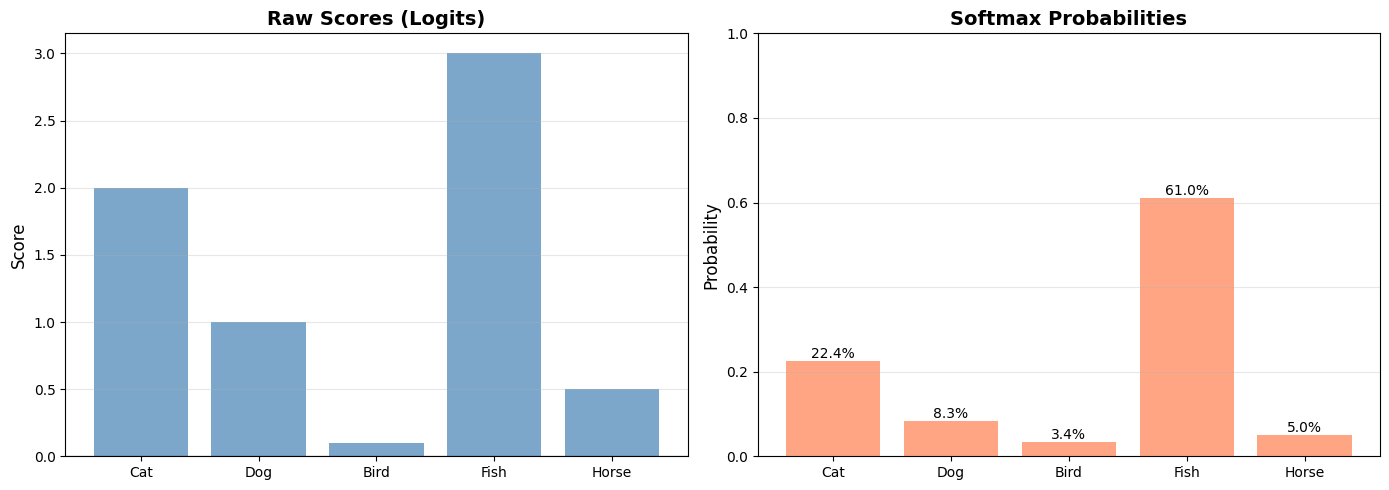

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot raw scores
ax1.bar(class_names, logits, color='steelblue', alpha=0.7)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Raw Scores (Logits)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.8)

# Plot softmax probabilities
bars = ax2.bar(class_names, probabilities, color='coral', alpha=0.7)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Softmax Probabilities', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{prob*100:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Example 2: Temperature Parameter

Temperature scaling controls how "sharp" or "smooth" the probability distribution is:

### What does "sharp" vs "smooth" mean?

**Sharp distribution (Low temperature, T < 1):**
- The highest probability value becomes **much larger** than others
- Clear winner with little uncertainty
- The model is very **confident** in its prediction
- Probabilities are concentrated on one or few options

**Smooth distribution (High temperature, T > 1):**
- Probabilities are more **evenly spread** across all options
- More uncertainty, less decisive
- The model is **less confident** about which option is best
- Probabilities become more uniform (closer to each other)

### Real-world examples:

**When to use LOW temperature (sharp, confident):**
- **Final predictions in production**: When you need the model to make a decisive choice (e.g., spam vs not spam)
- **Argmax sampling**: When you want to pick the most likely next word in text generation
- **High-stakes decisions**: Medical diagnosis where you want clear, confident predictions

**When to use HIGH temperature (smooth, diverse):**
- **Creative text generation**: Making chatbot responses more diverse and interesting (less repetitive)
- **Exploration in RL**: Encouraging a reinforcement learning agent to explore different actions
- **Data augmentation**: Generating varied training examples
- **Brainstorming**: When you want multiple plausible options rather than just the top choice

In [5]:
def softmax_with_temperature(x, temperature=1.0):
    """Softmax with temperature parameter"""
    x = x / temperature
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

In [6]:
# Concrete example: Next word prediction in text generation
# Imagine predicting the next word after "I love eating"

word_scores = np.array([3.5, 2.8, 1.2, 0.5])  # Logits for: pizza, pasta, salad, broccoli
words = ['pizza', 'pasta', 'salad', 'broccoli']

print("Next word prediction: 'I love eating ___'\n")
print("=" * 60)

# Low temperature (T=0.5) - Sharp, confident
print("\n🔥 LOW TEMPERATURE (T=0.5) - Sharp/Confident:")
probs_low = softmax_with_temperature(word_scores, temperature=0.5)
for word, prob in zip(words, probs_low):
    print(f"  {word:12s}: {prob:.4f} ({prob*100:5.2f}%) {'█' * int(prob*50)}")
print(f"  → Model is VERY confident: picks '{words[np.argmax(probs_low)]}' almost always")

# Normal temperature (T=1.0) - Balanced
print("\n⚖️  NORMAL TEMPERATURE (T=1.0) - Balanced:")
probs_normal = softmax_with_temperature(word_scores, temperature=1.0)
for word, prob in zip(words, probs_normal):
    print(f"  {word:12s}: {prob:.4f} ({prob*100:5.2f}%) {'█' * int(prob*50)}")
print(f"  → Moderate confidence")

# High temperature (T=2.0) - Smooth, diverse
print("\n🌊 HIGH TEMPERATURE (T=2.0) - Smooth/Diverse:")
probs_high = softmax_with_temperature(word_scores, temperature=2.0)
for word, prob in zip(words, probs_high):
    print(f"  {word:12s}: {prob:.4f} ({prob*100:5.2f}%) {'█' * int(prob*50)}")
print(f"  → More diverse: 'broccoli' now has a reasonable chance!")

print("\n" + "=" * 60)
print(f"Probability difference (max - min):")
print(f"  T=0.5: {probs_low.max() - probs_low.min():.4f} (very sharp)")
print(f"  T=1.0: {probs_normal.max() - probs_normal.min():.4f} (balanced)")
print(f"  T=2.0: {probs_high.max() - probs_high.min():.4f} (smoother)")

Next word prediction: 'I love eating ___'


🔥 LOW TEMPERATURE (T=0.5) - Sharp/Confident:
  pizza       : 0.7942 (79.42%) ███████████████████████████████████████
  pasta       : 0.1958 (19.58%) █████████
  salad       : 0.0080 ( 0.80%) 
  broccoli    : 0.0020 ( 0.20%) 
  → Model is VERY confident: picks 'pizza' almost always

⚖️  NORMAL TEMPERATURE (T=1.0) - Balanced:
  pizza       : 0.6073 (60.73%) ██████████████████████████████
  pasta       : 0.3016 (30.16%) ███████████████
  salad       : 0.0609 ( 6.09%) ███
  broccoli    : 0.0302 ( 3.02%) █
  → Moderate confidence

🌊 HIGH TEMPERATURE (T=2.0) - Smooth/Diverse:
  pizza       : 0.4455 (44.55%) ██████████████████████
  pasta       : 0.3140 (31.40%) ███████████████
  salad       : 0.1411 (14.11%) ███████
  broccoli    : 0.0994 ( 9.94%) ████
  → More diverse: 'broccoli' now has a reasonable chance!

Probability difference (max - min):
  T=0.5: 0.7922 (very sharp)
  T=1.0: 0.5771 (balanced)
  T=2.0: 0.3461 (smoother)


In [7]:
# Additional test with different temperatures
scores = np.array([2.0, 1.0, 0.1])
temperatures = [0.5, 1.0, 2.0]

print("Effect of temperature on softmax:\n")
for temp in temperatures:
    probs = softmax_with_temperature(scores, temperature=temp)
    print(f"Temperature = {temp:.1f}: {probs}")
    print(f"  Max probability: {probs.max():.4f}\n")

Effect of temperature on softmax:

Temperature = 0.5: [0.86377712 0.11689952 0.01932336]
  Max probability: 0.8638

Temperature = 1.0: [0.65900114 0.24243297 0.09856589]
  Max probability: 0.6590

Temperature = 2.0: [0.50168776 0.30428901 0.19402324]
  Max probability: 0.5017



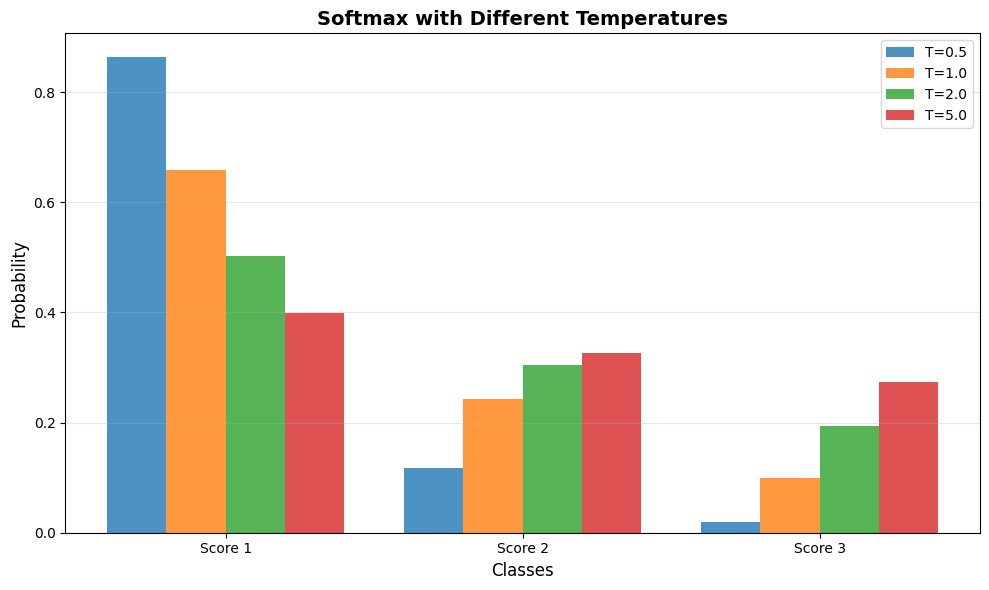


Key insight:
• Low temperature (T < 1): Sharper distribution, more confident
• High temperature (T > 1): Smoother distribution, less confident


In [8]:
# Visualize temperature effect
plt.figure(figsize=(10, 6))

temperatures = [0.5, 1.0, 2.0, 5.0]
x_labels = ['Score 1', 'Score 2', 'Score 3']
x_pos = np.arange(len(scores))
width = 0.2

for i, temp in enumerate(temperatures):
    probs = softmax_with_temperature(scores, temperature=temp)
    plt.bar(x_pos + i*width, probs, width, 
            label=f'T={temp}', alpha=0.8)

plt.xlabel('Classes', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Softmax with Different Temperatures', fontsize=14, fontweight='bold')
plt.xticks(x_pos + width*1.5, x_labels)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("• Low temperature (T < 1): Sharper distribution, more confident")
print("• High temperature (T > 1): Smoother distribution, less confident")